# Stock market trend prediction

### This project focuses on analyzing Tesla’s stock price time series to detect and forecast market trends (bullish, bearish, or neutral). It begins with traditional statistical and technical indicator methods, then progressively integrates advanced machine learning and deep learning algorithms to improve the accuracy and responsiveness of trend detection. The outcome is a comparative study and prototype capable of automatically identifying the current trend and predicting potential reversals.

By Thomas Jin, Thibault Gauthé, Yijia Zhang

In [20]:
import pandas as pd
import ta
import seaborn as sns
import numpy as np
from math import ceil
import matplotlib.pyplot as plt


In [21]:
data = pd.read_csv('Tesla_Stock_Data.csv')
data.head()

,Date,Close,High,Low,Open,Volume
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


### Nettoyage du dataset

In [22]:
data.describe()

,Close,High,Low,Open,Volume
count,3843.000000,3843.000000,3843.000000,3843.000000,3.843000e+03
mean,93.887965,95.992401,91.689924,93.911160,9.699445e+07
std,118.694016,121.435014,115.877610,118.784407,7.621392e+07
min,1.053333,1.108667,0.998667,1.076000,1.777500e+06
25%,12.691667,12.888667,12.409000,12.613667,5.086650e+07
50%,19.454000,19.888000,19.115999,19.483334,8.339850e+07
75%,200.739998,204.591667,195.213333,200.466667,1.222820e+08
max,479.859985,488.540009,457.510010,475.899994,9.140820e+08


In [23]:
data.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

### Dataset is already a cleaned one...

### Add analytic column

In [24]:
# Rendement journalier
data["Return_1d"] = data["Close"].pct_change()
# Moyennes mobiles
data["MA10"] = data["Close"].rolling(10).mean()
data["MA50"] = data["Close"].rolling(50).mean()
data["MA200"] = data["Close"].rolling(200).mean()
# Volatilité glissante
data["Volatility_20d"] = data["Return_1d"].rolling(20).std()
# RSI
data["RSI_14"] = ta.momentum.rsi(data["Close"], window=14)
# MACD + signal
macd = ta.trend.MACD(data["Close"])
data["MACD"] = macd.macd()
data["Signal"] = macd.macd_signal()

In [25]:
data.head()

,Date,Close,High,Low,Open,Volume,Return_1d,MA10,MA50,MA200,Volatility_20d,RSI_14,MACD,Signal
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500,-0.002511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000,-0.078473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000,-0.125683,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500,-0.160937,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 1 if bullish day, 0 if bearish day
data["Trend"] = (data["Close"].shift(-1) > data["Close"]).astype(int)
data.head()

,Date,Close,High,Low,Open,Volume,Return_1d,MA10,MA50,MA200,Volatility_20d,RSI_14,MACD,Signal,Trend
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500,-0.002511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000,-0.078473,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000,-0.125683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500,-0.160937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


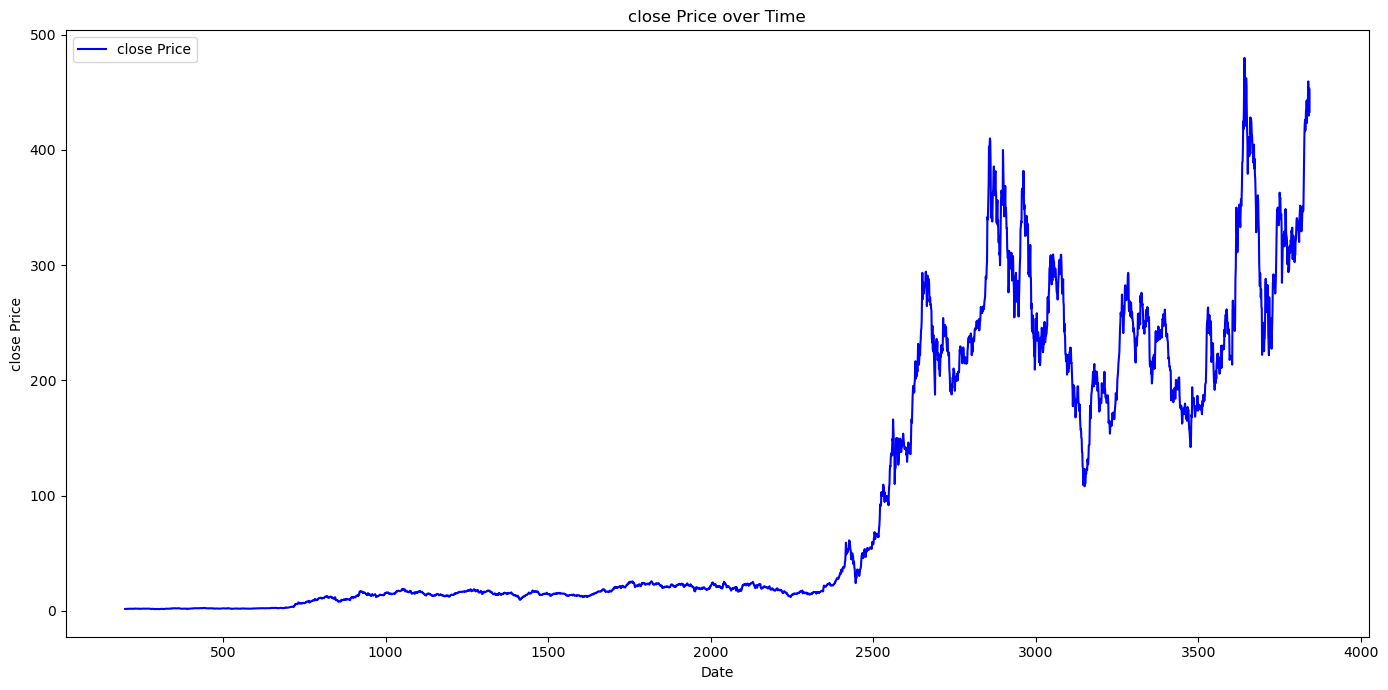

In [40]:
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Close'], label='close Price', color='blue')
plt.xlabel('Date')
plt.ylabel('close Price')
plt.title('close Price over Time')
plt.legend()
plt.tight_layout()
plt.show()

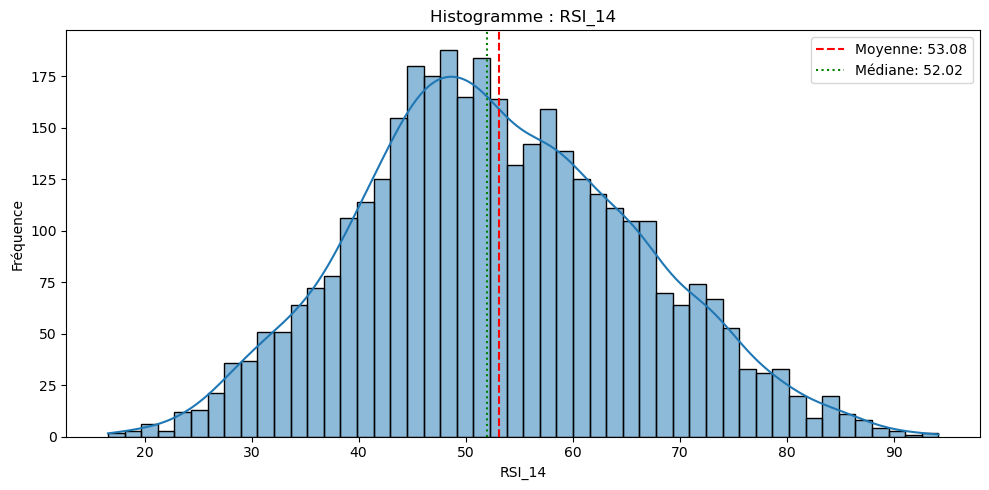

In [41]:
# histogramme de la colonne RSI (détecte automatiquement RSI_14 si présent)
rsi_cols = [c for c in df_vis.columns if 'RSI' in c.upper()]
if not rsi_cols:
    print("Aucune colonne RSI trouvée dans df_vis.")
else:
    rsi_col = rsi_cols[0]
    plt.figure(figsize=(10,5))
    sns.histplot(df_vis[rsi_col].dropna(), kde=True, bins=50, color='tab:blue')
    mean = df_vis[rsi_col].mean()
    median = df_vis[rsi_col].median()
    plt.axvline(mean, color='red', linestyle='--', label=f'Moyenne: {mean:.2f}')
    plt.axvline(median, color='green', linestyle=':', label=f'Médiane: {median:.2f}')
    plt.title(f'Histogramme : {rsi_col}')
    plt.xlabel(rsi_col)
    plt.ylabel('Fréquence')
    plt.legend()
    plt.tight_layout()
    plt.show()

### We can see here that some value are missing because in order to get those you have to get the values of the 50/100/200 previous one

### Final cleaning step

In [28]:
data = data.dropna()
data.isnull().sum()

Date              0
Close             0
High              0
Low               0
Open              0
Volume            0
Return_1d         0
MA10              0
MA50              0
MA200             0
Volatility_20d    0
RSI_14            0
MACD              0
Signal            0
Trend             0
dtype: int64

In [29]:
data.head()

,Date,Close,High,Low,Open,Volume,Return_1d,MA10,MA50,MA200,Volatility_20d,RSI_14,MACD,Signal,Trend
199,2011-04-12,1.643333,1.680667,1.620000,1.672000,20361000,-0.024535,1.738600,1.597293,1.581757,0.045385,49.263004,0.040834,0.035176,1
200,2011-04-13,1.662000,1.712667,1.654000,1.675333,18172500,0.011359,1.746733,1.598653,1.582103,0.045344,50.769372,0.035204,0.035181,1
201,2011-04-14,1.676000,1.685333,1.613333,1.658000,14751000,0.008424,1.729333,1.600253,1.582540,0.045328,51.922269,0.031508,0.034447,1
202,2011-04-15,1.705333,1.745333,1.694000,1.710000,14152500,0.017502,1.722133,1.602853,1.583747,0.045404,54.335217,0.030593,0.033676,0
203,2011-04-18,1.668667,1.708000,1.624000,1.675333,15508500,-0.021501,1.716800,1.604947,1.585690,0.045693,50.896591,0.026603,0.032261,1


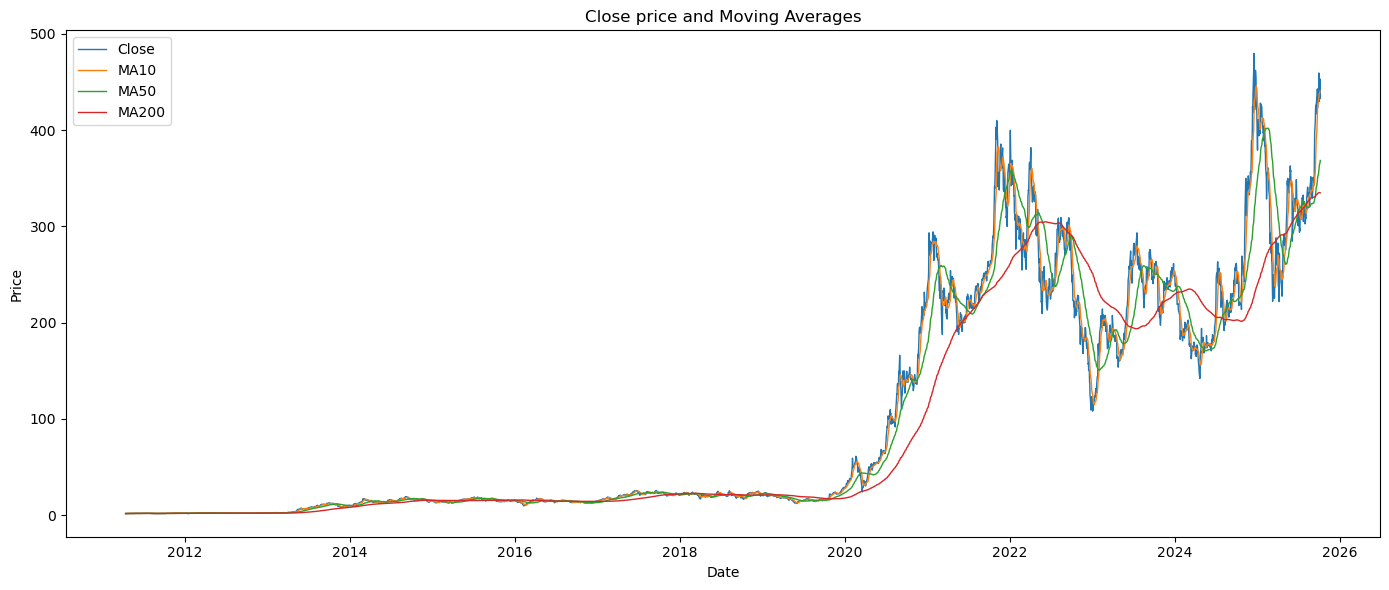

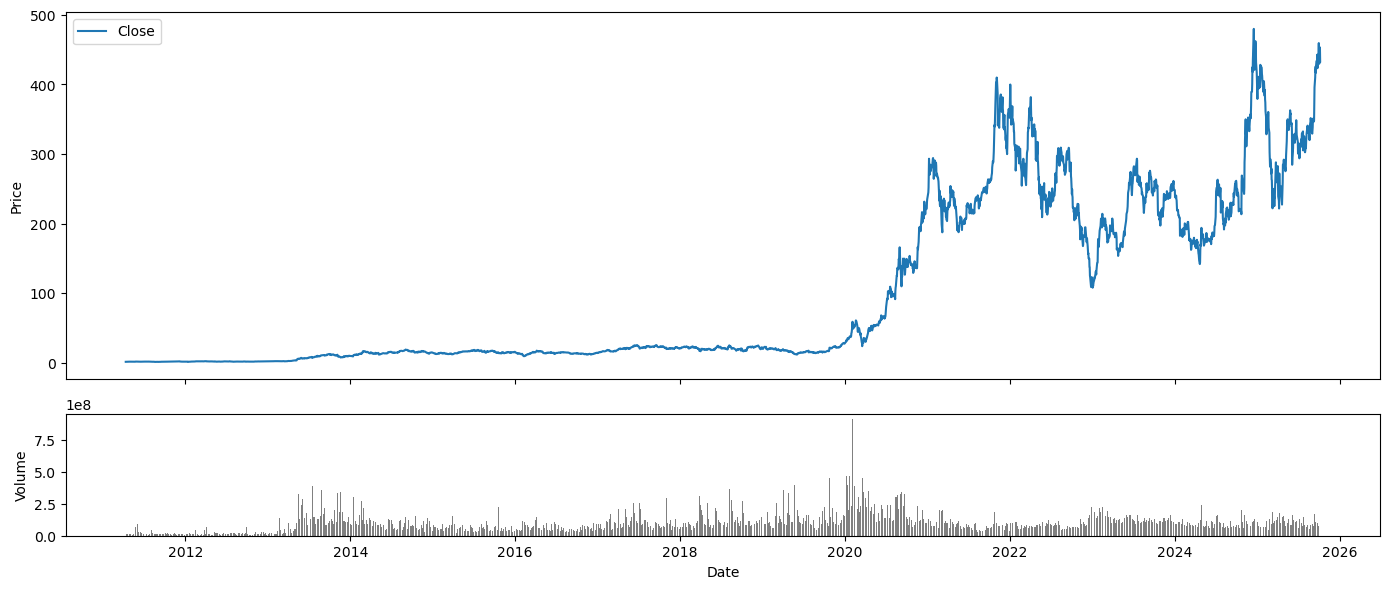

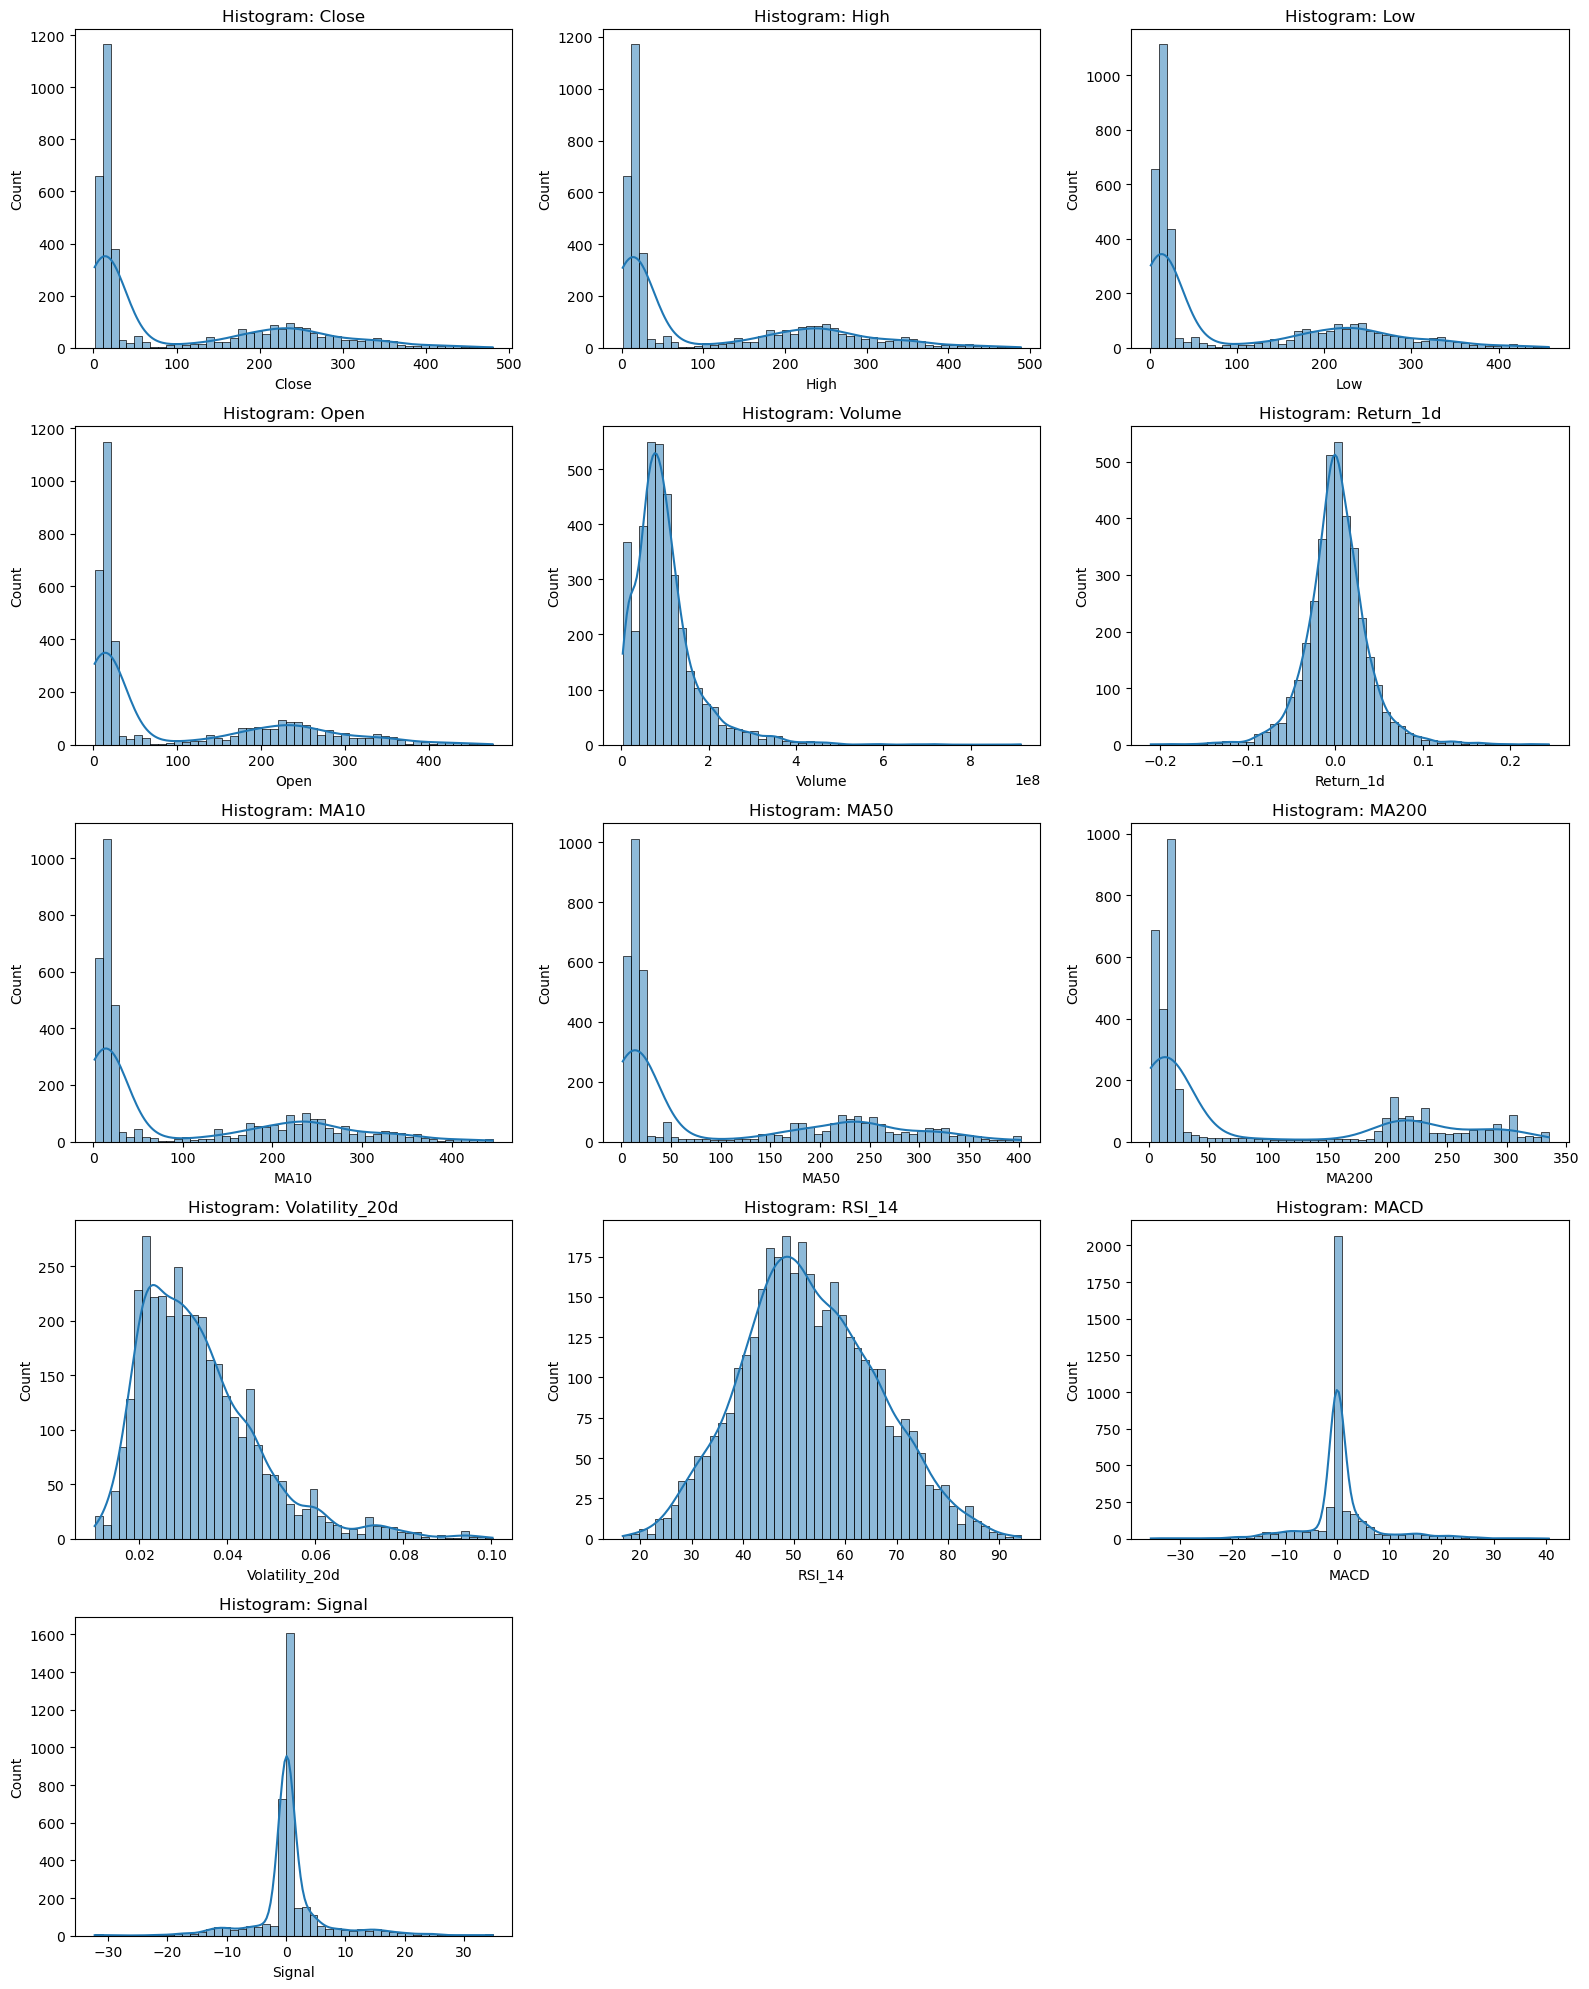

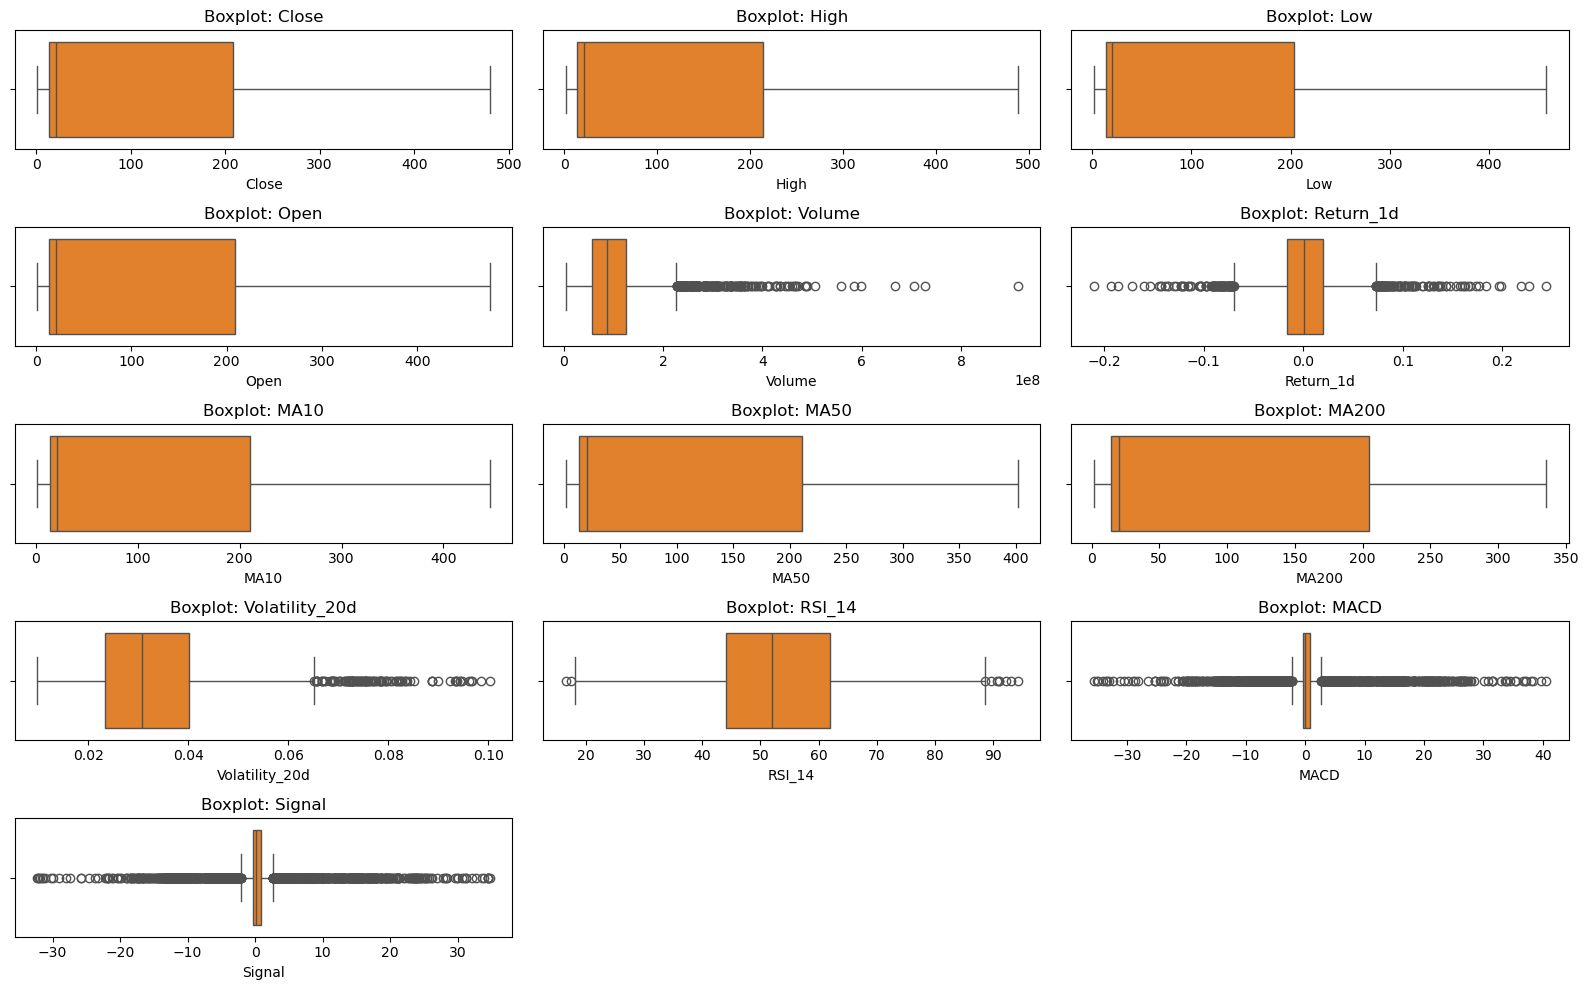

C:\Users\TJN22\AppData\Local\Temp\ipykernel_13220\3154297674.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Trend', data=df_vis, palette='pastel')


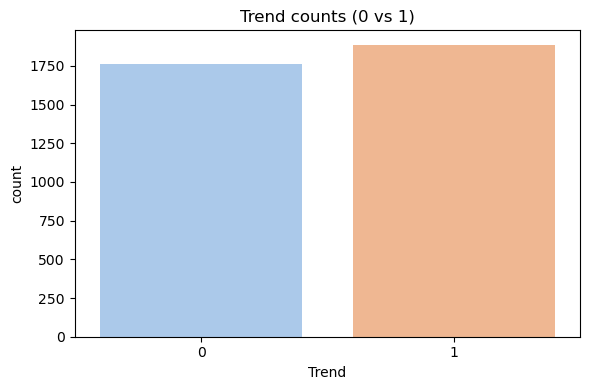

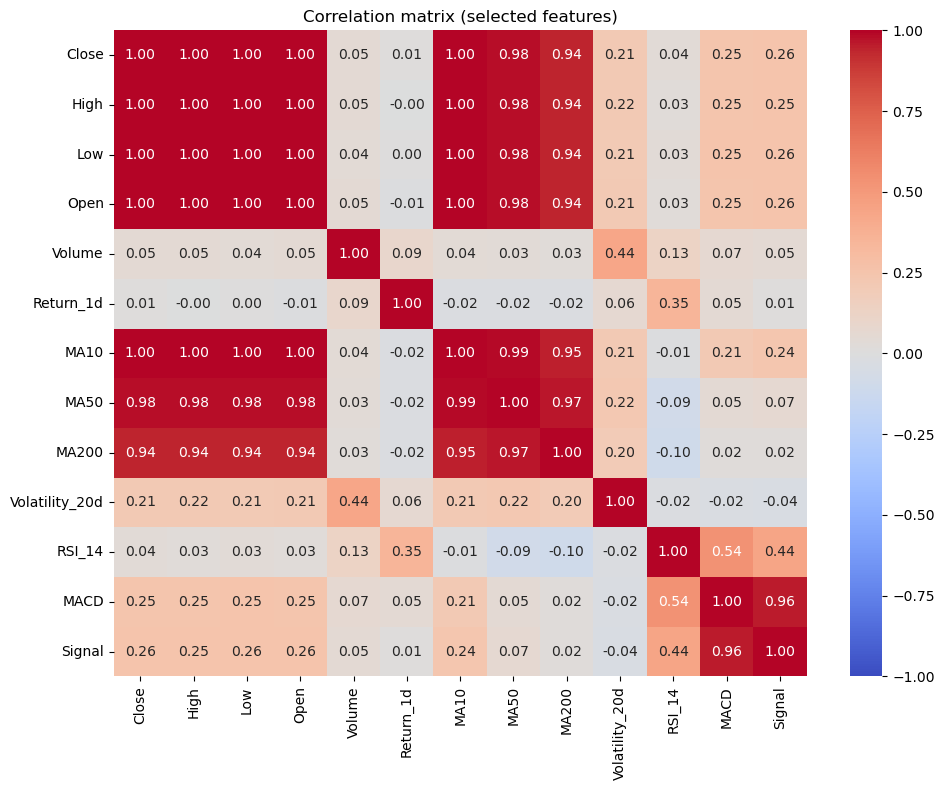

In [31]:

# prepare a working copy so we don't overwrite original `data`
df_vis = data.copy()
df_vis['Date'] = pd.to_datetime(df_vis['Date'])
df_vis = df_vis.set_index('Date')

# 1) Time series: Close + moving averages
plt.figure(figsize=(14,6))
plt.plot(df_vis.index, df_vis['Close'], label='Close', linewidth=1)
for ma in ['MA10', 'MA50', 'MA200']:
    if ma in df_vis.columns:
        plt.plot(df_vis.index, df_vis[ma], label=ma, linewidth=1)
plt.legend()
plt.title('Close price and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# 2) Price + volume (volume as bar on a shared x-axis)
fig, ax = plt.subplots(2, 1, figsize=(14,6), gridspec_kw={'height_ratios':[3,1]}, sharex=True)
ax[0].plot(df_vis.index, df_vis['Close'], label='Close', color='tab:blue')
ax[0].set_ylabel('Price')
ax[0].legend(loc='upper left')
ax[1].bar(df_vis.index, df_vis['Volume'], color='gray', width=1)
ax[1].set_ylabel('Volume')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

# 3) Histograms (with KDE) for numeric columns
cols = ['Close','High','Low','Open','Volume','Return_1d','MA10','MA50','MA200',
        'Volatility_20d','RSI_14','MACD','Signal']
cols = [c for c in cols if c in df_vis.columns]
n = len(cols)
ncols = 3
nrows = ceil(n / ncols)
plt.figure(figsize=(16, 4 * nrows))
for i, col in enumerate(cols, 1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(df_vis[col].dropna(), kde=True, bins=50, color='tab:blue')
    plt.title(f'Histogram: {col}')
plt.tight_layout()
plt.show()

# 4) Boxplots to inspect outliers
plt.figure(figsize=(16, 2 * nrows))
for i, col in enumerate(cols, 1):
    plt.subplot(nrows, ncols, i)
    sns.boxplot(x=df_vis[col].dropna(), orient='h', color='tab:orange')
    plt.title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

# 5) Trend distribution (categorical)
plt.figure(figsize=(6,4))
sns.countplot(x='Trend', data=df_vis, palette='pastel')
plt.title('Trend counts (0 vs 1)')
plt.tight_layout()
plt.show()

# 6) Correlation heatmap for the numeric columns
plt.figure(figsize=(10,8))
sns.heatmap(df_vis[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix (selected features)')
plt.tight_layout()
plt.show()